Import libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

Load dataset

In [2]:
columns = [
    "class","alcohol","malic_acid","ash","alcalinity_of_ash",
    "magnesium","total_phenols","flavanoids","nonflavanoid_phenols",
    "proanthocyanins","color_intensity","hue",
    "od280/od315_of_diluted_wines","proline"
]

df = pd.read_csv('/content/wine.data', header=None, names=columns)
df['SampleId'] = range(1, len(df)+1)

Split features and target

In [3]:
X = df.drop(['class','SampleId'], axis=1)
y = df['class']

Train Test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Standardize features

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic regression on original data

In [6]:
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train_scaled, y_train)

y_pred_orig = lr.predict(X_test_scaled)

acc_orig = accuracy_score(y_test, y_pred_orig)
f1_orig = f1_score(y_test, y_pred_orig, average='weighted')

print("Original Accuracy:", acc_orig)
print("Original F1 Score:", f1_orig)

Original Accuracy: 0.9814814814814815
Original F1 Score: 0.9815749306918357


LDA with component 1

In [7]:
lda1 = LinearDiscriminantAnalysis(n_components=1)

X_train_lda1 = lda1.fit_transform(X_train_scaled, y_train)
X_test_lda1 = lda1.transform(X_test_scaled)

lr1 = LogisticRegression(max_iter=5000)
lr1.fit(X_train_lda1, y_train)

y_pred_lda1 = lr1.predict(X_test_lda1)

acc_lda1 = accuracy_score(y_test, y_pred_lda1)
f1_lda1 = f1_score(y_test, y_pred_lda1, average='weighted')

print("LDA (1D) Accuracy:", acc_lda1)
print("LDA (1D) F1 Score:", f1_lda1)

LDA (1D) Accuracy: 0.9074074074074074
LDA (1D) F1 Score: 0.9077871457726923


LDA with components 2

In [8]:
lda2 = LinearDiscriminantAnalysis(n_components=2)

X_train_lda2 = lda2.fit_transform(X_train_scaled, y_train)
X_test_lda2 = lda2.transform(X_test_scaled)

lr2 = LogisticRegression(max_iter=5000)
lr2.fit(X_train_lda2, y_train)

y_pred_lda2 = lr2.predict(X_test_lda2)

acc_lda2 = accuracy_score(y_test, y_pred_lda2)
f1_lda2 = f1_score(y_test, y_pred_lda2, average='weighted')

print("LDA (2D) Accuracy:", acc_lda2)
print("LDA (2D) F1 Score:", f1_lda2)

LDA (2D) Accuracy: 0.9814814814814815
LDA (2D) F1 Score: 0.9814930627938757


Save LDA projection file

In [9]:
lda_full = LinearDiscriminantAnalysis(n_components=2)
X_lda_full = lda_full.fit_transform(StandardScaler().fit_transform(X), y)

lda_df = pd.DataFrame(X_lda_full, columns=['LD1','LD2'])
lda_df['SampleId'] = df['SampleId']
lda_df['Class'] = y

lda_df = lda_df[['SampleId','LD1','LD2','Class']]
lda_df.to_csv('lda_projection.csv', index=False)

lda_df.head()

,SampleId,LD1,LD2,Class
0,1,-4.700244,1.979138,1
1,2,-4.301958,1.170413,1
2,3,-3.420720,1.429101,1
3,4,-4.205754,4.002871,1
4,5,-1.509982,0.451224,1


Visualization (2D LDA)

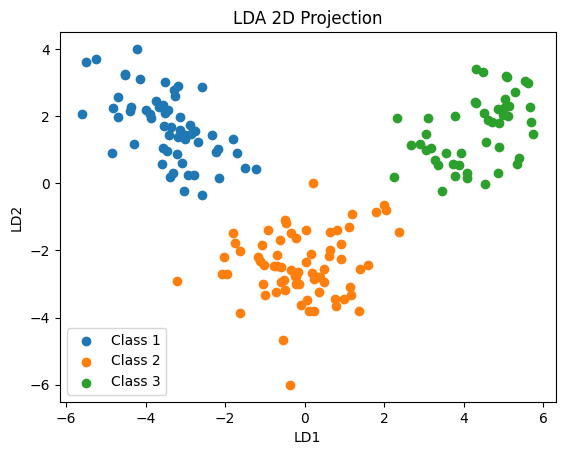

In [10]:
plt.figure()

for c in np.unique(y):
    plt.scatter(X_lda_full[y==c,0], X_lda_full[y==c,1], label=f'Class {c}')

plt.xlabel('LD1')
plt.ylabel('LD2')
plt.legend()
plt.title('LDA 2D Projection')
plt.show()

#Conclusion
Linear Discriminant Analysis (LDA) was applied to the Wine dataset to reduce dimensionality while maximizing class separability. The features were first standardized to ensure equal contribution to the model. LDA was then performed with 1 and 2 components, considering that the maximum number of components is (number of classes − 1).

The 1D projection resulted in reduced classification performance (Accuracy ≈ 0.907), indicating loss of discriminative information due to compression into a single dimension. In contrast, the 2D projection retained strong class separability, achieving Accuracy ≈ 0.981, which is comparable to the original dataset.

Visualization of the 2D LDA projection showed clearly separated clusters for the three wine classes, confirming effective discrimination.

LDA differs from Principal Component Analysis (PCA) as it is a supervised method that uses class labels to maximize separability, whereas PCA is unsupervised and focuses only on variance.

Overall, LDA successfully reduced dimensionality from 13 features to 2 while preserving classification performance, demonstrating its effectiveness for supervised dimensionality reduction tasks.